## Download image dataset from kaggle

In [1]:
import opendatasets as od

In [2]:
od.download("https://www.kaggle.com/datasets/shashanks1202/skin-cancer-dataset")

Skipping, found downloaded files in ".\skin-cancer-dataset" (use force=True to force download)


## Explore dataset

In [3]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

In [4]:
DATA_DIR = './skin-cancer-dataset/train_cancer/'

#### Let's walk through dataset

In [5]:
for root,folders,files in os.walk(DATA_DIR):
    print(f"{root} have {folders} folders with {len(files)} images")

./skin-cancer-dataset/train_cancer/ have ['benign', 'malignant'] folders with 0 images
./skin-cancer-dataset/train_cancer/benign have [] folders with 30 images
./skin-cancer-dataset/train_cancer/malignant have [] folders with 240 images


*with these few data i will be using transfer learning and fine-tune(if necessary)

#### Plotting random images and check some informations

In [6]:
def plotRandomImage(path=DATA_DIR, randomClass=random.choice(os.listdir(DATA_DIR))):
    randomImg = random.choice(os.listdir(os.path.join(DATA_DIR, randomClass)))
    imgPath = os.path.join(DATA_DIR, randomClass, randomImg)
    img = mpimg.imread(imgPath)

    print(f"""
           Image shape:{img.shape}
           Image data type: {img.dtype}
           Max value: {img.max()}
           Min value: {img.min()}""")
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.axis(False)
    plt.title(randomClass)
    plt.show()


           Image shape:(224, 224, 3)
           Image data type: uint8
           Max value: 251
           Min value: 22


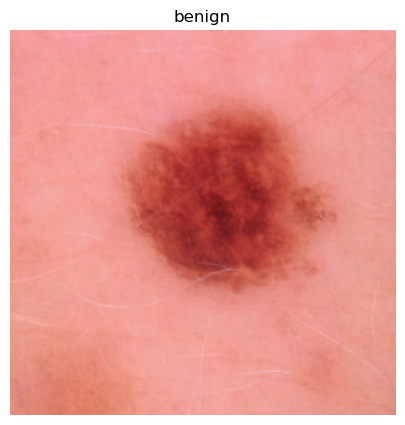

In [7]:
plotRandomImage()

we can see that we have RGB color channel so the values w'll be between [0,255] for that reason i will preprocess the images ,rescalling them so the values will be between [0,1], and with that casting the value from uint8 to float32.

## Load dataset using TensorFlow image_dataset_from_directory

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [9]:
(train_data, test_data) = image_dataset_from_directory(DATA_DIR,
                                                       image_size=(224,224),
                                                       batch_size=None,
                                                       label_mode='binary',
                                                       shuffle=True,
                                                       seed=123,
                                                       validation_split=0.4,
                                                       subset='both')

Found 270 files belonging to 2 classes.
Using 162 files for training.
Using 108 files for validation.


#### Preprocessing the images

In [10]:
def preprocessImages(img, label):
    rescaledImage = img/255.
    return tf.cast(rescaledImage, tf.float32), label

In [11]:
train_dataset= train_data.map(map_func=preprocessImages, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_data.map(map_func=preprocessImages, num_parallel_calls=tf.data.AUTOTUNE)

#### let's check the changes

Image dtype:<dtype: 'float32'>
Image shape:(224, 224, 3)
Image min/max values:48.0/214.0


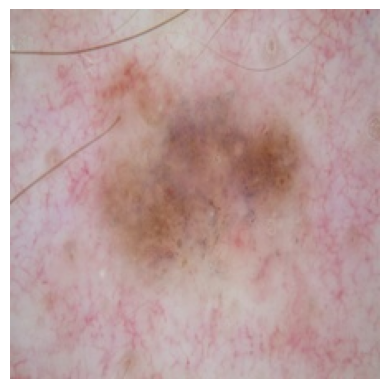

In [47]:
for img, label in train_data.take(1):
    print(f'Image dtype:{img.dtype}\nImage shape:{img.shape}\nImage min/max values:{tf.reduce_min(img)}/{tf.reduce_max(img)}')
    plt.imshow(img/255.)
    plt.axis(False)
    

#### Getting datasets ready, batching and prefecthing

In [13]:
train_dataset = train_data.batch(16).prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = test_data.batch(16).prefetch(buffer_size=tf.data.AUTOTUNE)

## Using Functional API to define a model

In [14]:
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

In [15]:
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)

In [16]:
base_model.trainable=False # freezing all the model's layers

In [17]:
# check if layers are froozen (last 20)
for layer in base_model.layers[-20:]:
    print(layer.name, layer.trainable)

block6g_drop False
block6g_add False
block6h_expand_conv False
block6h_expand_bn False
block6h_expand_activation False
block6h_dwconv2 False
block6h_bn False
block6h_activation False
block6h_se_squeeze False
block6h_se_reshape False
block6h_se_reduce False
block6h_se_expand False
block6h_se_excite False
block6h_project_conv False
block6h_project_bn False
block6h_drop False
block6h_add False
top_conv False
top_bn False
top_activation False


In [18]:
#### Constructing the model with Functional API
inputs = layers.Input(shape=(224,224,3), dtype=tf.float32, name='input_layer')
x = base_model(inputs, training=False) # sets model in inference mode
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(1, activation='sigmoid', name='output_layer')(x)
model_0 = tf.keras.Model(inputs, outputs, name='efficientnetv2b0_model')

In [19]:
## compilling the model
model_0.compile(loss='binary_crossentropy',
              optimizer=Adam(),
              metrics=['accuracy'])

In [20]:
## check model's summary
model_0.summary()

Model: "efficientnetv2b0_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetv2-b0 (Function  (None, None, None, 1280)  5919312  
 al)                                                             
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 output_layer (Dense)        (None, 1)                 1281      
                                                                 
Total params: 5,920,593
Trainable params: 1,281
Non-trainable params: 5,919,312
_________________________________________________________________


In [21]:
## creation of a helper function
def modelCheckpoint(path='./ModelExperiments/', model_name=None):
    return tf.keras.callbacks.ModelCheckpoint(filepath=f'{path}{model_name}', save_best_only=True,)

In [22]:
## Fit the model
model_0_history = model_0.fit(train_dataset, 
                              epochs=5, 
                              steps_per_epoch=len(train_dataset),
                              validation_data=test_dataset,
                              validation_steps=int(0.20*len(test_dataset)))#validates only on 20% of the test data

Epoch 1/5
11/11 [==============================] - 12s 459ms/step - loss: 0.5382 - accuracy: 0.7716 - val_loss: 0.4365 - val_accuracy: 0.8125
Epoch 2/5
11/11 [==============================] - 3s 296ms/step - loss: 0.3174 - accuracy: 0.8889 - val_loss: 0.4274 - val_accuracy: 0.8125
Epoch 3/5
11/11 [==============================] - 3s 291ms/step - loss: 0.2867 - accuracy: 0.8889 - val_loss: 0.3762 - val_accuracy: 0.8125
Epoch 4/5
11/11 [==============================] - 3s 295ms/step - loss: 0.2541 - accuracy: 0.8889 - val_loss: 0.2836 - val_accuracy: 0.8750
Epoch 5/5
11/11 [==============================] - 3s 291ms/step - loss: 0.2199 - accuracy: 0.9136 - val_loss: 0.2311 - val_accuracy: 0.8750


## Fine-tune

In [23]:
base_model.trainable=True

In [24]:
## compilling the model
model_0.compile(loss='binary_crossentropy',
              optimizer=Adam(0.0001),
              metrics=['accuracy'])

In [ ]:
## Fit the model
model_0_history_fine_tune = model_0.fit(train_dataset, 
                                        epochs=10, 
                                        steps_per_epoch=len(train_dataset),
                                        validation_data=test_dataset,
                                        validation_steps=int(0.20*len(test_dataset)),
                                        callbacks=[modelCheckpoint(model_name=model_0.name)],
                                        initial_epoch=model_0_history.epoch[-1])

## Evaluating the model

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
import numpy as np

In [27]:
model_0.evaluate(test_dataset)

7/7 [==============================] - 3s 462ms/step - loss: 0.1339 - accuracy: 0.9630


[0.13393789529800415, 0.9629629850387573]

In [28]:
model = tf.keras.models.load_model('./ModelExperiments/efficientnetv2b0_model')

In [29]:
model.evaluate(test_dataset)

7/7 [==============================] - 4s 373ms/step - loss: 0.1339 - accuracy: 0.9630


[0.13393789529800415, 0.9629629850387573]

In [32]:
y_true=[]
for _, label in test_dataset.unbatch():
    y_true.append(label)

In [37]:
y_true = np.array(y_true).flatten()

In [38]:
y_true

array([1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 1., 1.], dtype=float32)

In [39]:
y_pred_probs = model.predict(test_dataset)

7/7 [==============================] - 4s 369ms/step


In [40]:
y_pred = tf.squeeze(tf.round(y_pred_probs))

96.30%


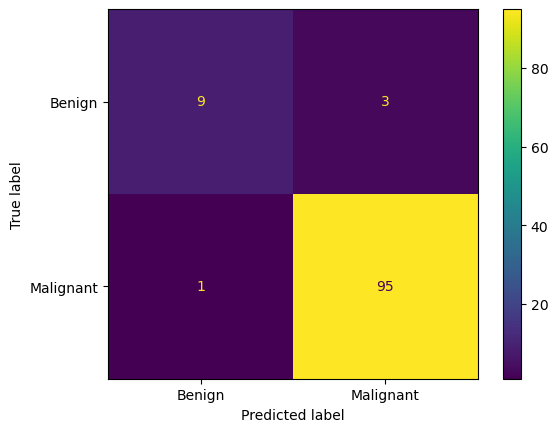

              precision    recall  f1-score   support

         0.0       0.90      0.75      0.82        12
         1.0       0.97      0.99      0.98        96

    accuracy                           0.96       108
   macro avg       0.93      0.87      0.90       108
weighted avg       0.96      0.96      0.96       108



In [48]:
print(f'{accuracy_score(y_true, y_pred)*100:.2f}%')
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm,display_labels=['Benign','Malignant'])
disp.plot()
plt.show()
print(classification_report(y_true, y_pred))